# TF-IDF Baseline — Semantic Similarity

## Goal
Establish a baseline for semantic similarity using TF-IDF.
This is Version 1 — the simplest possible approach.

## Question
How well can word overlap measure semantic similarity?
Where does it succeed and where does it fail?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## 1. Define Test Sentences
Three groups: similar meaning, different words — to stress-test TF-IDF.

In [2]:
# Sentence pairs — grouped by semantic similarity
sentences = {
    "Group A — ML": [
        "Machine learning models learn from data",
        "AI systems improve through training on examples",
        "Algorithms extract patterns from datasets",
    ],
    "Group B — Weather": [
        "The weather today is sunny and warm",
        "It is a beautiful clear day outside",
        "The sky is bright and the temperature is high",
    ],
    "Group C — Food": [
        "I love eating pizza and pasta",
        "Italian cuisine is my favorite food",
        "Nothing beats a good slice of pizza",
    ]
}

all_sentences = [s for group in sentences.values() for s in group]

print(f"Total sentences: {len(all_sentences)}")
for group, sents in sentences.items():
    print(f"\n{group}:")
    for s in sents:
        print(f" - {s}")

Total sentences: 9

Group A — ML:
 - Machine learning models learn from data
 - AI systems improve through training on examples
 - Algorithms extract patterns from datasets

Group B — Weather:
 - The weather today is sunny and warm
 - It is a beautiful clear day outside
 - The sky is bright and the temperature is high

Group C — Food:
 - I love eating pizza and pasta
 - Italian cuisine is my favorite food
 - Nothing beats a good slice of pizza


## 2. Compute TF-IDF Similarity Matrix

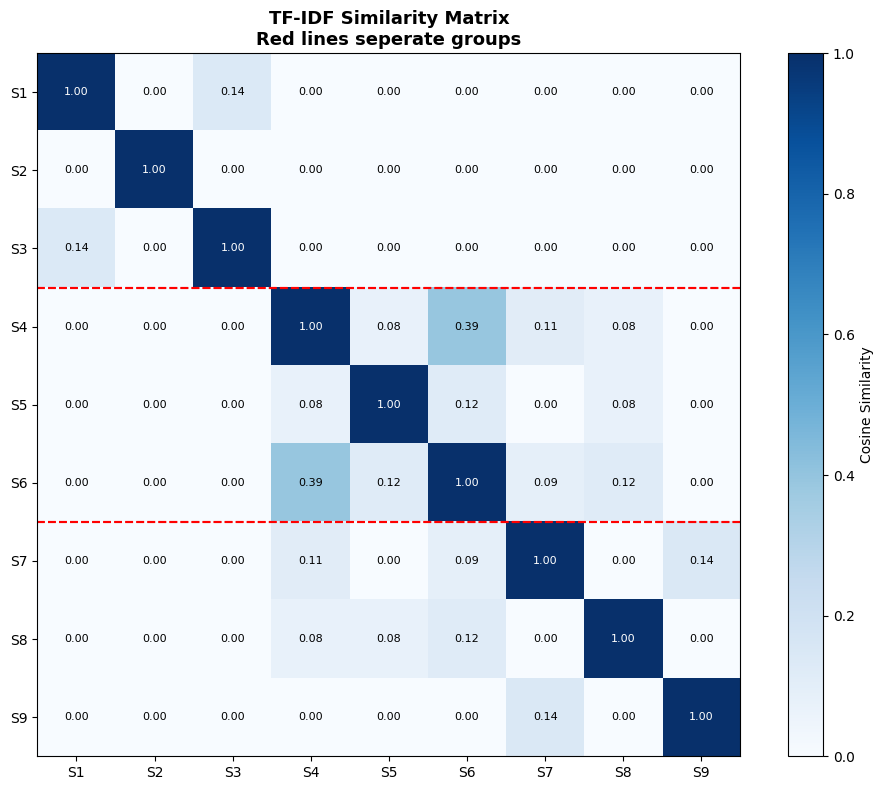

In [7]:
# Vectorize
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(all_sentences)

# Compute pairwise similarity
sim_matrix = cosine_similarity(tfidf_matrix)

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))

labels = [f"S{i+1}" for i in range(len(all_sentences))]
im = ax.imshow(sim_matrix, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(all_sentences)))
ax.set_yticks(range(len(all_sentences)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(len(all_sentences)):
    for j in range(len(all_sentences)):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}",
               ha="center", va="center", fontsize=8,
               color="white" if sim_matrix[i,j] > 0.5 else "black")

# Add group dividers
for line in [2.5, 5.5]:
    ax.axhline(line, color="red", linewidth=1.5, linestyle="--")
    ax.axhline(line, color="red", linewidth=1.5, linestyle="--")

plt.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_title("TF-IDF Similarity Matrix\nRed lines seperate groups",
            fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("tfidf_similarity_matrix.png", dpi=300)
plt.show()
    

## 3. Key Findings

| Pair | Similarity | Expected | Result |
|------|-----------|----------|--------|
| S1 vs S2 (ML sentences) | 0.00 | High | FAIL |
| S4 vs S6 (Weather) | 0.39 | High | Partial |
| S7 vs S9 (Food — pizza) | 0.14 | High | FAIL |

## Why TF-IDF Fails Here
- "Machine learning" and "AI systems" — no shared words
- "sunny and warm" and "bright and high temperature" — no shared words
- "eating pizza" and "slice of pizza" — only "pizza" matches

## Baseline Score
TF-IDF captures similarity only when sentences share exact vocabulary.
For semantic similarity, this is a fundamental limitation.

## Next
Can sentence embeddings do better?
-> 02_sentence_embeddings.ipynb